In [3]:
# =========================================================
# INSTALLATION
# =========================================================
# Qiskit 1.x moved its simulator into a separate package (qiskit-aer).
# pylatexenc is required for rendering circuit diagrams with qc.draw("mpl").
# matplotlib / numpy are usually preinstalled in Colab but are listed for completeness.

!pip install qiskit qiskit-aer pylatexenc matplotlib numpy

  Using cached pylatexenc-2.11-py2.py3-none-any.whl.metadata (3.9 kB)
  Using cached rustworkx-0.18.1-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (10 kB)
  Using cached stevedore-5.9.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 61.1 MB/s eta 0:00:00
Using cached pylatexenc-2.11-py2.py3-none-any.whl (137 kB)
Using cached rustworkx-0.18.1-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (2.4 MB)
Using cached stevedore-5.9.1-py3-none-any.whl (54 kB)


## Scientific Context

A short, accurate refresher on the concepts this experiment relies on:

**Qubit** — The basic unit of quantum information. Unlike a classical bit (strictly 0 or 1),
a qubit's state is described by a vector in a two-dimensional complex vector space,
conventionally written as α|0⟩ + β|1⟩, with |α|² + |β|² = 1.

**Superposition** — A qubit can exist in a combination of |0⟩ and |1⟩ simultaneously
(in the mathematical sense above) until it is measured.

**Hadamard gate (H)** — A single-qubit gate that transforms a definite state into an equal
superposition:

    H|0⟩ = (1/√2) (|0⟩ + |1⟩)

**Probability amplitudes & the Born rule** — The complex coefficients α, β are called
probability amplitudes. The Born rule states that the probability of measuring a given outcome
equals the squared magnitude of its amplitude. For H|0⟩: P(0) = 0.5 and P(1) = 0.5.

**Measurement** — Measuring a qubit forces it to "choose" one classical outcome (0 or 1)
according to these probabilities. This process is irreversible and probabilistic — it is the
point where quantum information becomes classical information.

**Classical measurement outcomes** — Once measured, qubits behave exactly like classical bits:
fixed values of 0 or 1 that can be read, stored, and processed with ordinary code. Everything
downstream of measurement in this notebook (bit slicing, integer conversion, color mapping) is
classical computation on those outcomes.

In [4]:
# =========================================================
# IMPORTS
# =========================================================
%matplotlib inline

# --- Quantum computing ---
from qiskit import QuantumCircuit

try:
    from qiskit_aer import AerSimulator
except ImportError as import_error:
    raise ImportError(
        "Could not import qiskit_aer. Please run the installation cell above, "
        "then (if needed) go to Runtime -> Restart runtime, and re-run the notebook "
        "from the top."
    ) from import_error

from qiskit.visualization import plot_histogram

# --- Numerical computing ---
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Utilities ---
import random
from typing import List, Tuple, Optional, Dict

print("Imports successful.")

Imports successful.


In [5]:
# =========================================================
# CONFIGURATION
# =========================================================
# All experiment parameters live here so the rest of the notebook
# never contains unexplained "magic numbers".

# Reproducibility: seeds the Aer simulator's internal RNG only.
# Set to None to allow a different measurement outcome on every run.
SEED: Optional[int] = 42

# --- Demonstration circuit (used to visualize the measurement distribution) ---
NUM_QUBITS_DEMO = 4       # kept small so all 2^4 = 16 outcomes can be shown clearly
SHOTS_DEMO = 2000         # number of repeated circuit executions for the demo histogram

# --- Color-generation parameters ---
BITS_PER_CHANNEL = 8                               # standard 8-bit color channel (0-255)
NUM_CHANNELS = 3                                   # Red, Green, Blue
BITS_PER_COLOR = BITS_PER_CHANNEL * NUM_CHANNELS   # 24 qubits/bits needed to build ONE RGB color

COLORS_TO_GENERATE = 10   # size of the quantum-derived color palette

# --- Backend ---
SIMULATOR_BACKEND_NAME = "aer_simulator"  # Qiskit Aer's standard simulator

# --- Sanity checks: fail fast with a clear message rather than a cryptic error later ---
assert NUM_QUBITS_DEMO >= 1, "NUM_QUBITS_DEMO must be at least 1"
assert SHOTS_DEMO >= 1, "SHOTS_DEMO must be at least 1"
assert BITS_PER_COLOR == 24, "This notebook's mapping explanation assumes 24 bits per color"
assert COLORS_TO_GENERATE >= 1, "COLORS_TO_GENERATE must be at least 1"

print(f"Configuration loaded: {BITS_PER_COLOR} bits required per generated color "
      f"({NUM_CHANNELS} channels x {BITS_PER_CHANNEL} bits).")

Configuration loaded: 24 bits required per generated color (3 channels x 8 bits).


## How the Quantum Randomness Works

The circuit used throughout this notebook is deliberately simple:


For a single qubit:

    H|0⟩ = (1/√2)(|0⟩ + |1⟩)   ⇒   P(0) = 0.5,  P(1) = 0.5

Because every qubit is initialized independently and receives its own Hadamard gate, the
qubits are **not entangled** — the overall state is simply a tensor product of n identical
single-qubit superpositions:

    H^⊗n |0⟩^⊗n = (1/√(2^n)) Σ_x |x⟩      for x = 0 .. 2^n - 1

This means all 2^n possible bitstrings are, ideally, equally likely — each with probability
1/2^n. Measuring this circuit once produces one random n-bit string; repeating it produces
multiple independent n-bit strings.

This is the entire source of randomness used in this experiment: **nothing more, nothing less.**

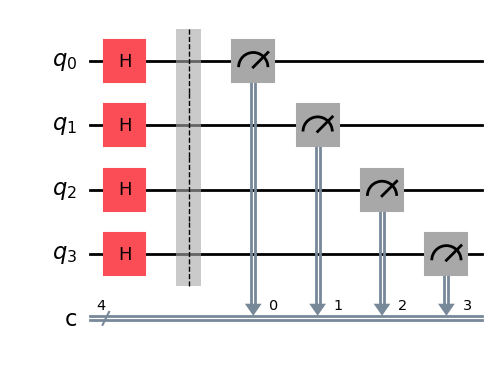

In [6]:
def build_hadamard_circuit(num_qubits: int) -> QuantumCircuit:
    """
    Build the core circuit used throughout this experiment:

        |0> --- H --- Measure   (repeated for every qubit)

    Each qubit is placed into an equal superposition with a Hadamard gate,
    then measured into its own classical bit. Ideally (noiseless simulation),
    every measured bit is 0 or 1 with probability 0.5, independently of the
    other qubits.

    Parameters
    ----------
    num_qubits : int
        Number of qubits (and classical bits) in the circuit. Must be >= 1.

    Returns
    -------
    QuantumCircuit
        The constructed circuit, not yet executed.
    """
    if num_qubits < 1:
        raise ValueError(f"num_qubits must be >= 1, got {num_qubits}")

    circuit = QuantumCircuit(num_qubits, num_qubits, name=f"H{num_qubits}_measure")
    circuit.h(range(num_qubits))
    circuit.barrier()  # visual separator only; has no effect on the physics
    circuit.measure(range(num_qubits), range(num_qubits))
    return circuit


# Build and display the small demonstration circuit
demo_circuit = build_hadamard_circuit(NUM_QUBITS_DEMO)
demo_circuit.draw("mpl")

In [7]:
def run_circuit_shots(circuit: QuantumCircuit, shots: int, seed: Optional[int] = None):
    """
    Execute `circuit` on Qiskit Aer's simulator for `shots` repetitions and
    return the qiskit Result object.

    `memory=True` asks Aer to also retain the individual outcome of every
    single shot (not just the aggregated counts), which we rely on later to
    turn each shot into an independent bitstring.

    Parameters
    ----------
    circuit : QuantumCircuit
        A circuit that includes measurements.
    shots : int
        Number of times to repeat the circuit execution.
    seed : Optional[int]
        Seed for Aer's internal RNG (reproducibility of the SIMULATION only).

    Returns
    -------
    qiskit.result.Result
    """
    backend = AerSimulator()
    run_kwargs: Dict[str, object] = {"shots": shots, "memory": True}
    if seed is not None:
        run_kwargs["seed_simulator"] = seed

    job = backend.run(circuit, **run_kwargs)
    return job.result()


# Run the demonstration circuit many times to observe the measurement distribution
demo_result = run_circuit_shots(demo_circuit, shots=SHOTS_DEMO, seed=SEED)
demo_counts = demo_result.get_counts()

total_shots = sum(demo_counts.values())
num_possible_outcomes = 2 ** NUM_QUBITS_DEMO
expected_count_per_outcome = total_shots / num_possible_outcomes

print(f"Backend: {SIMULATOR_BACKEND_NAME}")
print(f"Total shots executed: {total_shots}")
print(f"Distinct bitstrings observed: {len(demo_counts)} / {num_possible_outcomes} possible")
print(f"Expected count per outcome if perfectly uniform: {expected_count_per_outcome:.1f}")

Backend: aer_simulator
Total shots executed: 2000
Distinct bitstrings observed: 16 / 16 possible
Expected count per outcome if perfectly uniform: 125.0


In [8]:
# =========================================================
# VISUALIZE MEASUREMENT DISTRIBUTION
# =========================================================
if NUM_QUBITS_DEMO <= 6:
    # Small enough to show every observed outcome clearly
    fig = plot_histogram(
        demo_counts,
        figsize=(9, 4),
        title=f"Measurement Outcomes: {SHOTS_DEMO} shots, {NUM_QUBITS_DEMO} qubits (H + Measure)",
    )
    fig
else:
    # Too many possible bitstrings (2^n) to show all of them legibly;
    # show only the most frequent outcomes as a summary.
    TOP_N = 20
    top_items = sorted(demo_counts.items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]
    labels, values = zip(*top_items)

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values, color="#4C72B0")
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Counts")
    plt.title(f"Top {TOP_N} most frequent bitstrings out of {len(demo_counts)} observed "
              f"(truncated view — {NUM_QUBITS_DEMO} qubits, {SHOTS_DEMO} shots)")
    plt.tight_layout()
    plt.show()

print(
    "\nInterpretation: under an ideal simulation, each bitstring is equally likely. "
    "With a finite number of shots, small deviations from a perfectly flat distribution "
    "are normal statistical fluctuation, not evidence of bias."
)


Interpretation: under an ideal simulation, each bitstring is equally likely. With a finite number of shots, small deviations from a perfectly flat distribution are normal statistical fluctuation, not evidence of bias.


## From Bits to Colors

This section defines, explicitly, how a quantum-derived bitstring becomes a color. There is
no hidden logic — every step is a plain, deterministic transformation.

**Step 1 — How many bits does a color need?**

A standard 24-bit RGB color needs 8 bits per channel:

BITS_PER_CHANNEL = 8

---


NUM_CHANNELS = 3 (Red, Green, Blue)

---


BITS_PER_COLOR = 24 (= 8 x 3)

---




So we run a **24-qubit** Hadamard+Measure circuit to generate exactly enough bits for one color.

**Step 2 — Slice the bitstring**

The 24-bit measurement outcome is split into three consecutive 8-bit chunks, left to right:

bits[ 0: 8] -> R channel

---


bits[ 8:16] -> G channel

---


bits[16:24] -> B channel

---

**Step 3 — Convert each chunk to an integer**

Each 8-bit chunk is read as a standard binary number (leftmost = most significant bit):

"01010101" -> 85


**Step 4 — Assemble the color**
RGB = (R, G, B) # e.g. (85, 12, 240)

---


HEX = "#{R:02X}{G:02X}{B:02X}" # e.g. "#550CF0"




In [9]:
def generate_quantum_bits(num_bits: int, num_samples: int = 1, seed: Optional[int] = None) -> List[str]:
    """
    Generate one or more quantum-derived bitstrings.

    Method
    ------
    A fresh `num_bits`-qubit Hadamard+Measure circuit (see `build_hadamard_circuit`)
    is executed for `num_samples` shots. Because each shot is an independent
    execution of the same circuit, we obtain `num_samples` independent
    measurement outcomes — each one a bitstring of length `num_bits`.

    Parameters
    ----------
    num_bits : int
        Number of qubits (and bits) in each sample.
    num_samples : int
        How many independent bitstrings to generate.
    seed : Optional[int]
        Seed for Aer's internal RNG (reproducibility of the simulation only).

    Returns
    -------
    List[str]
        `num_samples` bitstrings, each of length `num_bits`, composed of '0'/'1'.
    """
    if num_bits < 1:
        raise ValueError(f"num_bits must be >= 1, got {num_bits}")
    if num_samples < 1:
        raise ValueError(f"num_samples must be >= 1, got {num_samples}")

    circuit = build_hadamard_circuit(num_bits)
    result = run_circuit_shots(circuit, shots=num_samples, seed=seed)
    bitstrings = result.get_memory()

    for bitstring in bitstrings:
        if len(bitstring) != num_bits or any(c not in "01" for c in bitstring):
            raise RuntimeError(
                f"Malformed bitstring returned by simulator: {bitstring!r} "
                f"(expected length {num_bits}, characters in {{'0','1'}})"
            )

    return bitstrings


# Quick sanity demonstration
_sample_bits = generate_quantum_bits(num_bits=8, num_samples=3, seed=SEED)
print("Example 8-bit quantum-derived samples:", _sample_bits)

Example 8-bit quantum-derived samples: ['00010001', '11111000', '01010111']


In [10]:
def bits_to_integer(bitstring: str) -> int:
    """
    Convert a binary string into its unsigned integer value using standard
    positional binary notation, reading LEFT to RIGHT as MOST to LEAST
    significant bit.

    Example
    -------
    "01010101" -> 0*128 + 1*64 + 0*32 + 1*16 + 0*8 + 1*4 + 0*2 + 1*1 = 85

    Parameters
    ----------
    bitstring : str
        A non-empty string containing only '0' and '1' characters.

    Returns
    -------
    int
    """
    if not bitstring or any(c not in "01" for c in bitstring):
        raise ValueError(f"Invalid bitstring: {bitstring!r}")
    return int(bitstring, 2)


# Demonstration matching the example in the markdown above
example = "01010101"
print(f"bits_to_integer({example!r}) = {bits_to_integer(example)}")

bits_to_integer('01010101') = 85


In [11]:
def quantum_bits_to_rgb(
    bits: str,
    bits_per_channel: int = BITS_PER_CHANNEL,
) -> Tuple[Tuple[int, int, int], str]:
    """
    Convert a quantum-derived bitstring into an (R, G, B) tuple and a HEX color code.

    Deterministic mapping
    ----------------------
    bits[0                  : bits_per_channel]     -> R channel
    bits[bits_per_channel   : 2*bits_per_channel]   -> G channel
    bits[2*bits_per_channel : 3*bits_per_channel]   -> B channel

    Each `bits_per_channel`-bit chunk is converted to an integer via
    `bits_to_integer`, matching the standard 0-255 range for 8-bit channels.

    Parameters
    ----------
    bits : str
        Bitstring of length >= 3 * bits_per_channel.
    bits_per_channel : int
        Number of bits assigned to each color channel (default 8).

    Returns
    -------
    (Tuple[int, int, int], str)
        The RGB tuple and the corresponding HEX string, e.g. ((255, 0, 128), "#FF0080").
    """
    required_bits = 3 * bits_per_channel
    if len(bits) < required_bits:
        raise ValueError(
            f"Need at least {required_bits} bits to build an RGB color, got {len(bits)}"
        )
    if any(c not in "01" for c in bits):
        raise ValueError(f"Bitstring contains non-binary characters: {bits!r}")

    r_bits = bits[0 * bits_per_channel: 1 * bits_per_channel]
    g_bits = bits[1 * bits_per_channel: 2 * bits_per_channel]
    b_bits = bits[2 * bits_per_channel: 3 * bits_per_channel]

    r = bits_to_integer(r_bits)
    g = bits_to_integer(g_bits)
    b = bits_to_integer(b_bits)

    hex_code = f"#{r:02X}{g:02X}{b:02X}"
    return (r, g, b), hex_code


# Quick sanity demonstration with a synthetic (non-quantum) example
_test_bits = "1" * 8 + "0" * 8 + "1" * 4 + "0" * 4
print(f"quantum_bits_to_rgb({_test_bits!r}) = {quantum_bits_to_rgb(_test_bits)}")

quantum_bits_to_rgb('111111110000000011110000') = ((255, 0, 240), '#FF00F0')


Quantum-derived bits (24 bits): 000100011111100001010111
RGB: (17, 248, 87)
HEX: #11F857


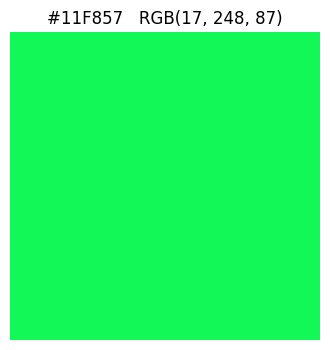

In [12]:
# =========================================================
# GENERATE ONE QUANTUM COLOR
# =========================================================
single_color_bits = generate_quantum_bits(num_bits=BITS_PER_COLOR, num_samples=1, seed=SEED)[0]
single_color_rgb, single_color_hex = quantum_bits_to_rgb(single_color_bits)

print(f"Quantum-derived bits ({BITS_PER_COLOR} bits): {single_color_bits}")
print(f"RGB: {single_color_rgb}")
print(f"HEX: {single_color_hex}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.add_patch(mpatches.Rectangle((0, 0), 1, 1, facecolor=np.array(single_color_rgb) / 255))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(f"{single_color_hex}   RGB{single_color_rgb}", fontsize=12)
plt.show()

In [13]:
# =========================================================
# GENERATE MULTIPLE QUANTUM COLORS
# =========================================================
def generate_quantum_color_palette(
    num_colors: int,
    bits_per_color: int = BITS_PER_COLOR,
    seed: Optional[int] = None,
) -> List[Dict[str, object]]:
    """
    Generate a palette of `num_colors` quantum-derived colors.

    Each color comes from an independent `bits_per_color`-bit measurement
    outcome (see `generate_quantum_bits`), so the whole palette originates
    from `num_colors` shots of the same underlying Hadamard+Measure circuit.

    Returns
    -------
    List[Dict[str, object]]
        One dict per color with keys: "bits", "rgb", "hex".
    """
    bitstrings = generate_quantum_bits(bits_per_color, num_samples=num_colors, seed=seed)

    palette = []
    for bits in bitstrings:
        rgb, hex_code = quantum_bits_to_rgb(bits, bits_per_channel=BITS_PER_CHANNEL)
        palette.append({"bits": bits, "rgb": rgb, "hex": hex_code})
    return palette


quantum_palette = generate_quantum_color_palette(COLORS_TO_GENERATE, seed=SEED)
print(f"Generated {len(quantum_palette)} quantum-derived colors.")

Generated 10 quantum-derived colors.


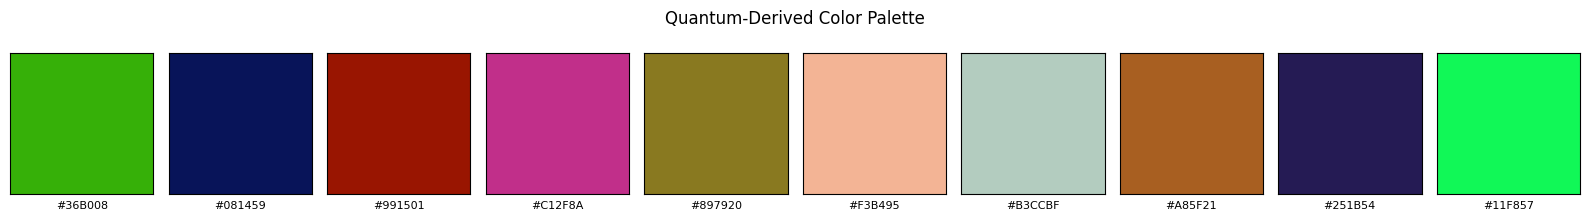

HEX       RGB               BITS
#36B008   (54, 176, 8)      001101101011000000001000
#081459   (8, 20, 89)       000010000001010001011001
#991501   (153, 21, 1)      100110010001010100000001
#C12F8A   (193, 47, 138)    110000010010111110001010
#897920   (137, 121, 32)    100010010111100100100000
#F3B495   (243, 180, 149)   111100111011010010010101
#B3CCBF   (179, 204, 191)   101100111100110010111111
#A85F21   (168, 95, 33)     101010000101111100100001
#251B54   (37, 27, 84)      001001010001101101010100
#11F857   (17, 248, 87)     000100011111100001010111


In [14]:
# =========================================================
# VISUALIZE QUANTUM PALETTE
# =========================================================
def plot_color_palette(palette: List[Dict[str, object]], title: str = "Color Palette") -> None:
    """
    Render a horizontal strip of color swatches with their HEX codes labeled.
    """
    n = len(palette)
    fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
    axes = np.atleast_1d(axes)

    for ax, color in zip(axes, palette):
        rgb = color["rgb"]
        ax.add_patch(mpatches.Rectangle((0, 0), 1, 1, facecolor=np.array(rgb) / 255))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(color["hex"], fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_color_palette(quantum_palette, title="Quantum-Derived Color Palette")

print(f"{'HEX':<10}{'RGB':<18}BITS")
for color in quantum_palette:
    print(f"{color['hex']:<10}{str(color['rgb']):<18}{color['bits']}")

## Understanding the Palette

If you re-run the quantum circuit, you will very likely get a **different palette**. This is
expected, and here is why:

- Quantum measurement, even in an ideal simulation, is fundamentally probabilistic. Each run
  samples from the same probability distribution but is not guaranteed to reproduce the same
  outcome (unless you fix `SEED`, which seeds the simulator's internal RNG for reproducibility).
- Different measurement outcomes produce different 24-bit strings.
- Different 24-bit strings map, deterministically, to different RGB values via the fixed
  procedure defined above.

**Important distinction:** the *randomness* in this experiment comes entirely from the quantum
measurement step. Everything after that — slicing bits, converting to integers, building RGB
tuples, rendering swatches — is ordinary deterministic computation. The palette displayed on
screen is not "quantum" in any physical sense; it is a classical visualization of classical
data that originated from a quantum measurement.

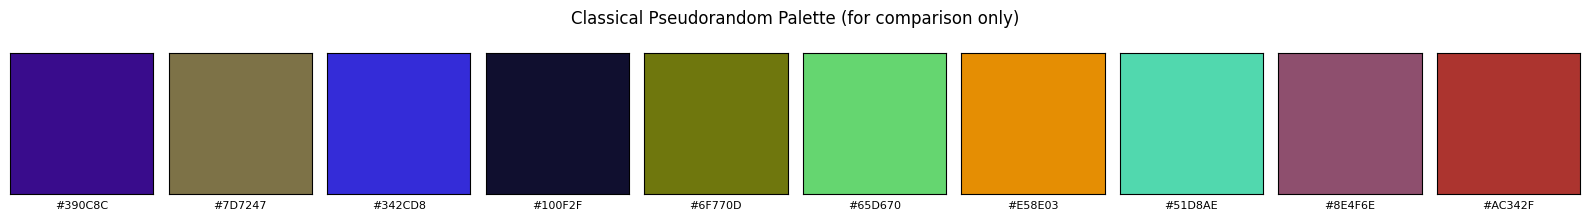

This palette is shown for comparison only. It is generated entirely by Python's standard-library pseudorandom generator and does not use any quantum measurement data.


In [15]:
# =========================================================
# COMPARE WITH CLASSICAL PSEUDORANDOMNESS
# =========================================================
# NOTE: This is the ONLY section of the notebook that uses classical
# pseudorandom numbers. It exists purely for side-by-side comparison and
# NEVER feeds into the quantum-derived colors generated above.

classical_rng = random.Random(SEED)  # standard library Mersenne Twister PRNG


def generate_classical_color_palette(num_colors: int, rng: random.Random) -> List[Dict[str, object]]:
    """
    Generate a palette of `num_colors` colors using Python's classical
    pseudorandom number generator (`random` module), for comparison only.
    """
    palette = []
    for _ in range(num_colors):
        r = rng.randint(0, 255)
        g = rng.randint(0, 255)
        b = rng.randint(0, 255)
        hex_code = f"#{r:02X}{g:02X}{b:02X}"
        palette.append({"rgb": (r, g, b), "hex": hex_code})
    return palette


classical_palette = generate_classical_color_palette(COLORS_TO_GENERATE, classical_rng)
plot_color_palette(classical_palette, title="Classical Pseudorandom Palette (for comparison only)")

print(
    "This palette is shown for comparison only. It is generated entirely by Python's "
    "standard-library pseudorandom generator and does not use any quantum measurement data."
)

=== Quantum-derived bit balance ===
Total bits sampled: 240
Zeros: 134 (55.8%)
Ones:  106 (44.2%)
(With so few samples, deviations from 50/50 are expected and NOT evidence of bias.)



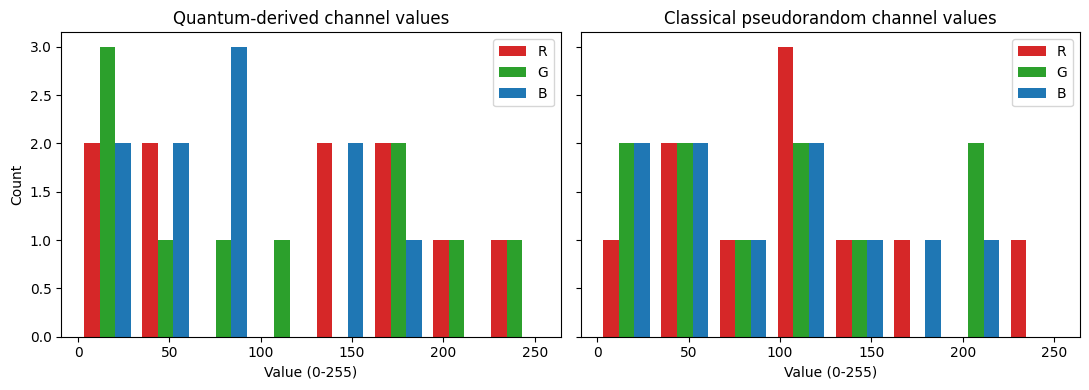

Sample size: 10 colors per method. This is far too small to draw statistical conclusions; it is shown for illustrative/educational purposes only.


In [16]:
# =========================================================
# SIMPLE STATISTICAL COMPARISON
# =========================================================
def bit_frequency(bitstrings: List[str]) -> Tuple[int, int]:
    """Count total '0' and '1' characters across a list of bitstrings."""
    joined = "".join(bitstrings)
    return joined.count("0"), joined.count("1")


quantum_bitstrings = [color["bits"] for color in quantum_palette]
zeros, ones = bit_frequency(quantum_bitstrings)
total_bits = zeros + ones

print("=== Quantum-derived bit balance ===")
print(f"Total bits sampled: {total_bits}")
print(f"Zeros: {zeros} ({zeros / total_bits:.1%})")
print(f"Ones:  {ones} ({ones / total_bits:.1%})")
print("(With so few samples, deviations from 50/50 are expected and NOT evidence of bias.)\n")

# Compare RGB channel value distributions: quantum-derived vs classical
quantum_r = [c["rgb"][0] for c in quantum_palette]
quantum_g = [c["rgb"][1] for c in quantum_palette]
quantum_b = [c["rgb"][2] for c in quantum_palette]

classical_r = [c["rgb"][0] for c in classical_palette]
classical_g = [c["rgb"][1] for c in classical_palette]
classical_b = [c["rgb"][2] for c in classical_palette]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist([quantum_r, quantum_g, quantum_b], bins=8, range=(0, 255),
             label=["R", "G", "B"], color=["#d62728", "#2ca02c", "#1f77b4"])
axes[0].set_title("Quantum-derived channel values")
axes[0].set_xlabel("Value (0-255)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist([classical_r, classical_g, classical_b], bins=8, range=(0, 255),
             label=["R", "G", "B"], color=["#d62728", "#2ca02c", "#1f77b4"])
axes[1].set_title("Classical pseudorandom channel values")
axes[1].set_xlabel("Value (0-255)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Sample size: {COLORS_TO_GENERATE} colors per method. "
      "This is far too small to draw statistical conclusions; it is shown "
      "for illustrative/educational purposes only.")

Requesting 2,073,600 quantum-measured bits (86,400 shots x 24 qubits)...
Bit field shape: (1080, 1920) (rows x cols)
Zeros: 1,036,093 (49.97%)
Ones:  1,037,507 (50.03%)


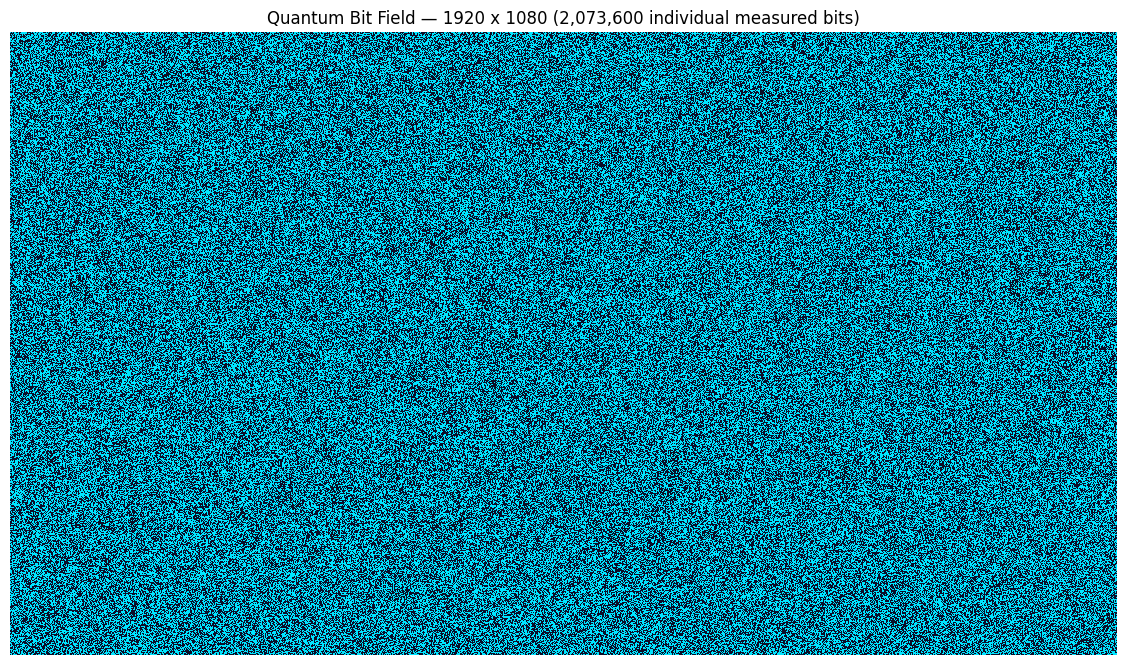

Saved full-resolution image to: quantum_bit_field_1920x1080.png


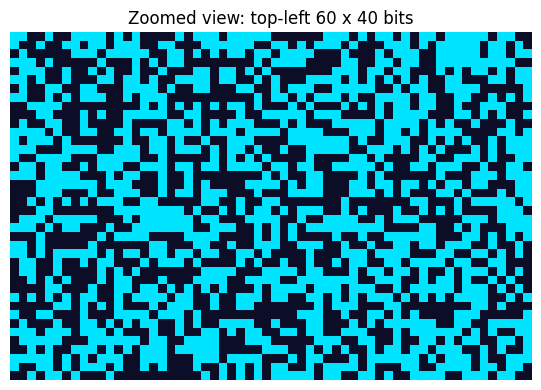

In [17]:
# =========================================================
# QUANTUM BIT-FIELD IMAGE (1920 x 1080, one pixel per bit)
# =========================================================

# --- Image configuration ---
IMAGE_WIDTH = 1920    # number of columns
IMAGE_HEIGHT = 1080   # number of bits stacked in each column (rows)

# Reuse the same 24-qubit circuit already defined earlier (build_hadamard_circuit).
# 1920 x 1080 = 2,073,600 bits, and 2,073,600 / 24 = 86,400 shots exactly -> no truncation.
QUBITS_PER_IMAGE_SHOT = BITS_PER_COLOR  # = 24, defined in the Configuration cell

TOTAL_BITS_NEEDED = IMAGE_WIDTH * IMAGE_HEIGHT
assert TOTAL_BITS_NEEDED % QUBITS_PER_IMAGE_SHOT == 0, (
    "IMAGE_WIDTH * IMAGE_HEIGHT must be divisible by QUBITS_PER_IMAGE_SHOT "
    "to avoid discarding or padding bits."
)
NUM_IMAGE_SHOTS = TOTAL_BITS_NEEDED // QUBITS_PER_IMAGE_SHOT

# Two colors used to render a bit's value. Purely a visualization choice -
# arbitrary but fully disclosed, exactly like the RGB channel mapping used earlier.
COLOR_FOR_BIT_0 = (12, 14, 40)     # deep indigo
COLOR_FOR_BIT_1 = (0, 229, 255)    # bright cyan


def generate_quantum_bit_field(
    num_rows: int,
    num_cols: int,
    qubits_per_shot: int,
    seed: Optional[int] = None,
) -> np.ndarray:
    """
    Generate a (num_rows x num_cols) grid of individual quantum measurement outcomes.

    Method
    ------
    1. Run a `qubits_per_shot`-qubit Hadamard+Measure circuit for enough shots to
       cover num_rows * num_cols bits exactly.
    2. Concatenate every shot's bitstring, in shot order, into one long bitstream.
    3. Reshape that bitstream into a (num_rows, num_cols) grid, filled row by row
       (row 0 gets the first num_cols bits, row 1 gets the next num_cols bits, etc.).

    Parameters
    ----------
    num_rows, num_cols : int
        Dimensions of the output bit grid.
    qubits_per_shot : int
        Number of qubits in each circuit execution. Must evenly divide
        num_rows * num_cols.
    seed : Optional[int]
        Seed for Aer's internal RNG (reproducibility of the simulation only).

    Returns
    -------
    np.ndarray
        A (num_rows, num_cols) array of dtype uint8 containing only 0s and 1s.
    """
    total_bits = num_rows * num_cols
    if total_bits % qubits_per_shot != 0:
        raise ValueError(
            f"num_rows * num_cols ({total_bits}) must be divisible by "
            f"qubits_per_shot ({qubits_per_shot})."
        )

    num_shots = total_bits // qubits_per_shot
    bitstrings = generate_quantum_bits(qubits_per_shot, num_samples=num_shots, seed=seed)

    combined_bits = "".join(bitstrings)
    if len(combined_bits) != total_bits:
        raise RuntimeError(
            f"Expected {total_bits} total bits, got {len(combined_bits)} "
            "from the simulator. This should not happen."
        )

    bit_values = np.array([int(ch) for ch in combined_bits], dtype=np.uint8)
    return bit_values.reshape(num_rows, num_cols)


def bit_field_to_rgb_image(
    bit_field: np.ndarray,
    color_for_0: Tuple[int, int, int],
    color_for_1: Tuple[int, int, int],
) -> np.ndarray:
    """
    Convert a 2D array of 0/1 bits into an (H, W, 3) uint8 RGB image, where every
    bit becomes exactly one pixel.

    Parameters
    ----------
    bit_field : np.ndarray
        2D array containing only 0s and 1s.
    color_for_0, color_for_1 : Tuple[int, int, int]
        RGB colors (0-255) assigned to bit value 0 and bit value 1, respectively.

    Returns
    -------
    np.ndarray
        RGB image array of shape (num_rows, num_cols, 3), dtype uint8.
    """
    if not np.all(np.isin(bit_field, [0, 1])):
        raise ValueError("bit_field must contain only 0s and 1s.")

    height, width = bit_field.shape
    image = np.zeros((height, width, 3), dtype=np.uint8)
    image[bit_field == 0] = np.array(color_for_0, dtype=np.uint8)
    image[bit_field == 1] = np.array(color_for_1, dtype=np.uint8)
    return image


# --- Generate the bit field from real (simulated) quantum measurement outcomes ---
print(f"Requesting {TOTAL_BITS_NEEDED:,} quantum-measured bits "
      f"({NUM_IMAGE_SHOTS:,} shots x {QUBITS_PER_IMAGE_SHOT} qubits)...")

quantum_bit_field = generate_quantum_bit_field(
    num_rows=IMAGE_HEIGHT,
    num_cols=IMAGE_WIDTH,
    qubits_per_shot=QUBITS_PER_IMAGE_SHOT,
    seed=SEED,
)

zero_count = int(np.sum(quantum_bit_field == 0))
one_count = int(np.sum(quantum_bit_field == 1))
print(f"Bit field shape: {quantum_bit_field.shape} (rows x cols)")
print(f"Zeros: {zero_count:,} ({zero_count / TOTAL_BITS_NEEDED:.2%})")
print(f"Ones:  {one_count:,} ({one_count / TOTAL_BITS_NEEDED:.2%})")

# --- Convert bits to a full-resolution RGB image ---
quantum_bit_image = bit_field_to_rgb_image(
    quantum_bit_field, COLOR_FOR_BIT_0, COLOR_FOR_BIT_1
)

# --- Display the full 1920x1080 image ---
plt.figure(figsize=(12, 6.75))
plt.imshow(quantum_bit_image, interpolation="nearest")
plt.axis("off")
plt.title(
    f"Quantum Bit Field — {IMAGE_WIDTH} x {IMAGE_HEIGHT} "
    f"({TOTAL_BITS_NEEDED:,} individual measured bits)"
)
plt.tight_layout()
plt.show()

# --- Save a pixel-exact PNG (1 image pixel = 1 measured bit, no resampling) ---
output_filename = "quantum_bit_field_1920x1080.png"
plt.imsave(output_filename, quantum_bit_image)
print(f"Saved full-resolution image to: {output_filename}")

# --- Zoomed inset so individual bit-pixels are actually visible ---
zoom_rows, zoom_cols = 40, 60  # small window size for a legible close-up
zoom_crop = quantum_bit_image[:zoom_rows, :zoom_cols]

plt.figure(figsize=(6, 4))
plt.imshow(zoom_crop, interpolation="nearest")
plt.axis("off")
plt.title(f"Zoomed view: top-left {zoom_cols} x {zoom_rows} bits")
plt.tight_layout()
plt.show()

## Bonus: Quantum Color Mosaic (1920 × 1080 individual quantum colors)

This extends the earlier "one quantum color" and "quantum palette" cells to full image scale.

**Goal:** produce a 1920 × 1080 image where **every single pixel is its own independent
quantum-derived RGB color** — not a single bit, a full color, generated the exact same way as
`Generate One Quantum Color` earlier in this notebook.

**Scale of the request:**

* Image size = 1920 x 1080 = 2,073,600 pixels
* Bits per pixel = 24 (same BITS_PER_COLOR used earlier: 8 bits x 3 channels)
* Total bits needed = 2,073,600 x 24 = 49,766,400 bits
* Total shots needed = 2,073,600 (ONE shot = ONE pixel's full RGB color)


Each pixel's color is produced with the **same 24-qubit Hadamard+Measure circuit** and the
**same `quantum_bits_to_rgb` mapping** already defined earlier — this cell simply runs that
process 2,073,600 times (once per pixel) instead of once or ten times.

**A technical note on feasibility:** this circuit contains only Hadamard gates and
measurements, which makes it a *Clifford circuit*. Qiskit Aer's `AerSimulator` automatically
detects this and uses an efficient stabilizer-based simulation method instead of a full
state-vector simulation. This is why generating over two million independent measurement
outcomes remains practical on the free Colab simulator — it is still the same simulated
circuit and measurement process used throughout the notebook, just executed many times.

**Performance note:** because looping a pure-Python function 2+ million times is slow, the
bulk bit → RGB conversion below uses an equivalent, vectorized NumPy implementation. Before
running it at scale, we explicitly verify that the vectorized math produces **identical**
results to the already-defined `quantum_bits_to_rgb()` function on a sample of pixels.

Mosaic size: 1920 x 1080 = 2,073,600 pixels
Each pixel = 1 independent quantum measurement shot (24 qubits)
Total shots required: 2,073,600
Total quantum-measured bits required: 49,766,400

Collected 2,073,600 independent quantum measurement outcomes.
Reference quantum_bits_to_rgb() verified on 5 sample bitstrings:
  011010011100010010010100 -> RGB (105, 196, 148)  HEX #69C494
  111001000111110100111011 -> RGB (228, 125, 59)  HEX #E47D3B
  011010100011001111000110 -> RGB (106, 51, 198)  HEX #6A33C6
  100100011100101000100000 -> RGB (145, 202, 32)  HEX #91CA20
  100010111110100100000010 -> RGB (139, 233, 2)  HEX #8BE902

Vectorized conversion verified to match quantum_bits_to_rgb() exactly on 5 sample pixels.

Quantum color mosaic array shape: (1080, 1920, 3) (rows, cols, RGB)


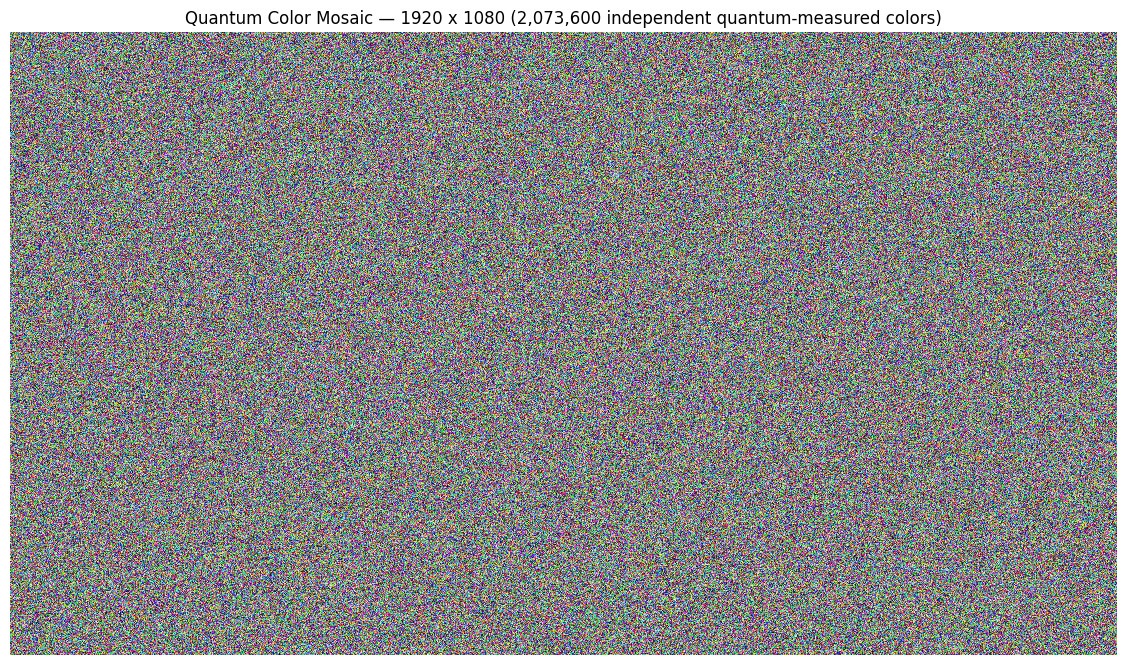

Saved full-resolution quantum color mosaic to: quantum_color_mosaic_1920x1080.png


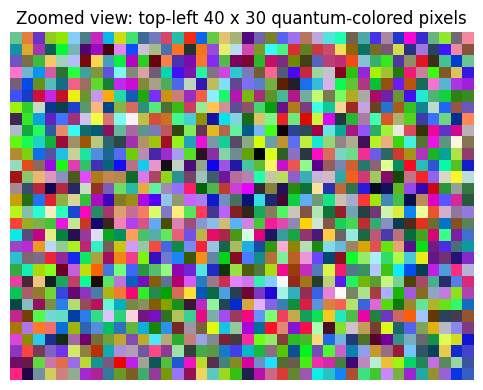

In [22]:
# =========================================================
# QUANTUM COLOR MOSAIC (1920 x 1080 individual quantum colors)
# =========================================================

# --- Mosaic configuration ---
MOSAIC_WIDTH = 1920      # columns
MOSAIC_HEIGHT = 1080     # rows
TOTAL_PIXELS = MOSAIC_WIDTH * MOSAIC_HEIGHT   # 2,073,600 independent quantum colors

# Each pixel needs its OWN independent 24-bit quantum measurement outcome,
# using the exact same circuit and mapping as the earlier "one quantum color" cells.
BITS_NEEDED_PER_PIXEL = BITS_PER_COLOR  # = 24, defined in the Configuration cell
TOTAL_BITS_NEEDED = TOTAL_PIXELS * BITS_NEEDED_PER_PIXEL

print(f"Mosaic size: {MOSAIC_WIDTH} x {MOSAIC_HEIGHT} = {TOTAL_PIXELS:,} pixels")
print(f"Each pixel = 1 independent quantum measurement shot ({BITS_NEEDED_PER_PIXEL} qubits)")
print(f"Total shots required: {TOTAL_PIXELS:,}")
print(f"Total quantum-measured bits required: {TOTAL_BITS_NEEDED:,}\n")


# ---------------------------------------------------------
# Step 1: run the SAME 24-qubit Hadamard+Measure circuit used earlier,
# once per pixel (one shot = one pixel's full RGB color).
# ---------------------------------------------------------
mosaic_bitstrings = generate_quantum_bits(
    num_bits=BITS_NEEDED_PER_PIXEL,
    num_samples=TOTAL_PIXELS,
    seed=SEED,
)

assert len(mosaic_bitstrings) == TOTAL_PIXELS, (
    f"Expected {TOTAL_PIXELS:,} quantum-measured bitstrings, got {len(mosaic_bitstrings):,}"
)
print(f"Collected {len(mosaic_bitstrings):,} independent quantum measurement outcomes.")


# ---------------------------------------------------------
# Step 2: sanity-check a small sample using the reference function
# already defined earlier (quantum_bits_to_rgb), before trusting the
# fast vectorized bulk conversion in Step 3.
# ---------------------------------------------------------
_sample_size = 5
_reference_results = [quantum_bits_to_rgb(bits) for bits in mosaic_bitstrings[:_sample_size]]
print(f"Reference quantum_bits_to_rgb() verified on {_sample_size} sample bitstrings:")
for bits, (rgb, hex_code) in zip(mosaic_bitstrings[:_sample_size], _reference_results):
    print(f"  {bits} -> RGB {rgb}  HEX {hex_code}")


# ---------------------------------------------------------
# Step 3: vectorized bits -> RGB conversion.
#
# This performs EXACTLY the same binary interpretation as
# bits_to_integer() / quantum_bits_to_rgb() (MSB-first, 8 bits per channel),
# just computed for all 2,073,600 pixels at once using NumPy instead of
# calling a pure-Python function once per pixel (which would be far slower).
# ---------------------------------------------------------
combined_bits_string = "".join(mosaic_bitstrings)
assert len(combined_bits_string) == TOTAL_BITS_NEEDED

# Reinterpret the ASCII '0'/'1' characters directly as small integers.
raw_bit_bytes = np.frombuffer(combined_bits_string.encode("ascii"), dtype=np.uint8)
bit_values = (raw_bit_bytes - ord("0")).astype(np.uint8)  # '0'/'1' characters -> 0/1 integers
bit_matrix = bit_values.reshape(TOTAL_PIXELS, BITS_NEEDED_PER_PIXEL)

# Positional binary weights for an 8-bit channel, MSB first: [128, 64, 32, ..., 1]
# (matches int(bitstring, 2), used inside bits_to_integer()).
channel_weights = (2 ** np.arange(BITS_PER_CHANNEL - 1, -1, -1)).astype(np.uint32)

r_bits = bit_matrix[:, 0 * BITS_PER_CHANNEL: 1 * BITS_PER_CHANNEL]
g_bits = bit_matrix[:, 1 * BITS_PER_CHANNEL: 2 * BITS_PER_CHANNEL]
b_bits = bit_matrix[:, 2 * BITS_PER_CHANNEL: 3 * BITS_PER_CHANNEL]

red_values = r_bits.astype(np.uint32) @ channel_weights
green_values = g_bits.astype(np.uint32) @ channel_weights
blue_values = b_bits.astype(np.uint32) @ channel_weights

# Cross-check the vectorized result against the trusted reference function.
for i in range(_sample_size):
    expected_rgb, _ = quantum_bits_to_rgb(mosaic_bitstrings[i])
    vectorized_rgb = (int(red_values[i]), int(green_values[i]), int(blue_values[i]))
    assert expected_rgb == vectorized_rgb, (
        f"Vectorized RGB mismatch at pixel {i}: {vectorized_rgb} != {expected_rgb}"
    )
print(f"\nVectorized conversion verified to match quantum_bits_to_rgb() exactly "
      f"on {_sample_size} sample pixels.")


# ---------------------------------------------------------
# Step 4: assemble the final (height, width, 3) image.
# Pixels are filled in row-major order: pixel 0 -> row 0 col 0,
# pixel 1 -> row 0 col 1, ..., pixel (width) -> row 1 col 0, etc.
# ---------------------------------------------------------
pixel_rgb_values = np.stack([red_values, green_values, blue_values], axis=1).astype(np.uint8)
quantum_color_mosaic = pixel_rgb_values.reshape(MOSAIC_HEIGHT, MOSAIC_WIDTH, 3)

print(f"\nQuantum color mosaic array shape: {quantum_color_mosaic.shape} (rows, cols, RGB)")


# ---------------------------------------------------------
# Step 5: display and save the full-resolution quantum color mosaic.
# ---------------------------------------------------------
plt.figure(figsize=(12, 6.75))
plt.imshow(quantum_color_mosaic, interpolation="nearest")
plt.axis("off")
plt.title(
    f"Quantum Color Mosaic — {MOSAIC_WIDTH} x {MOSAIC_HEIGHT} "
    f"({TOTAL_PIXELS:,} independent quantum-measured colors)"
)
plt.tight_layout()
plt.show()

# Save a pixel-exact PNG: 1 image pixel = 1 quantum-measured color, no resampling.
mosaic_filename = "quantum_color_mosaic_1920x1080.png"
plt.imsave(mosaic_filename, quantum_color_mosaic)
print(f"Saved full-resolution quantum color mosaic to: {mosaic_filename}")

# Zoomed inset so individual quantum-colored pixels are actually visible.
zoom_rows, zoom_cols = 30, 40  # small window size for a legible close-up
zoom_crop = quantum_color_mosaic[:zoom_rows, :zoom_cols]

plt.figure(figsize=(6, 4))
plt.imshow(zoom_crop, interpolation="nearest")
plt.axis("off")
plt.title(f"Zoomed view: top-left {zoom_cols} x {zoom_rows} quantum-colored pixels")
plt.tight_layout()
plt.show()